In [1]:
import pickle

with open(f"E:/fortransferee/mlproject7/imagecap/word2idx/kaggle/working/word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)

with open(f"E:/fortransferee/mlproject7/imagecap/idx2word/kaggle/working/idx2word.pkl", "rb") as f:
    idx2word = pickle.load(f)

vocab_size = len(word2idx)


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models

class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)

        # Remove avgpool + fc
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])

        for param in self.resnet.parameters():
            param.requires_grad = False

    def forward(self, images):
        features = self.resnet(images)
        # (B, 2048, 7, 7)

        features = features.permute(0, 2, 3, 1)
        # (B, 7, 7, 2048)

        features = features.view(features.size(0), -1, 2048)
        # (B, 49, 2048)

        return features



In [6]:
import torch
import torch.nn as nn

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()

        self.hidden_size = hidden_size  # ✅ STORE IT

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(2048, hidden_size, 512)
        self.lstm = nn.LSTMCell(embed_size + 2048, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)

        # ✅ USE self.hidden_size
        hidden = torch.zeros(batch_size, self.hidden_size).to(encoder_out.device)
        cell   = torch.zeros(batch_size, self.hidden_size).to(encoder_out.device)

        embeddings = self.embedding(captions[:, :-1])
        outputs = []

        for t in range(embeddings.size(1)):
            context = self.attention(encoder_out, hidden)
            lstm_input = torch.cat([embeddings[:, t], context], dim=1)
            hidden, cell = self.lstm(lstm_input, (hidden, cell))
            outputs.append(self.fc(hidden))

        return torch.stack(outputs, dim=1)




In [7]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, att_dim):
        super().__init__()
        self.enc = nn.Linear(encoder_dim, att_dim)
        self.dec = nn.Linear(decoder_dim, att_dim)
        self.fc = nn.Linear(att_dim, 1)

    def forward(self, encoder_out, hidden):
        att = self.fc(torch.tanh(
            self.enc(encoder_out) + self.dec(hidden).unsqueeze(1)
        )).squeeze(2)

        alpha = torch.softmax(att, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context


In [8]:

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = EncoderCNN().to(device)
decoder = DecoderRNN(
    embed_size=512,
    hidden_size=512,
    vocab_size=vocab_size
).to(device)


In [ ]:
encoder.load_state_dict(
    torch.load(f"E:/fortransferee/mlproject7/imagecap/encoder_attention/kaggle/working/encoder_attention.pth", map_location=device)
)

decoder.load_state_dict(
    torch.load(f"E:/fortransferee/mlproject7/imagecap/decoder_attention/kaggle/working/decoder_attention.pth", map_location=device)
)
# .pth files only store weights (numerical parameters), NOT the model architecture, therefore we need to define the model classes (EncoderCNN, DecoderRNN, Attention) exactly as they were during training before loading the weights.
encoder.eval()
decoder.eval()

print("✅ Model loaded successfully")


✅ Model loaded successfully


C:\Users\Palak Mathur\AppData\Local\Temp\ipykernel_12088\3614293181.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"E:/fortransferee/mlproject7/imagecap/enc

In [ ]:
import torch
from PIL import Image

#keeps the best sequences 
def beam_search(encoder_out, decoder, word2idx, idx2word, beam_size=3, max_len=20):
    device = encoder_out.device
    sequences = [([word2idx["<start>"]], 0.0)] #initlise the caption

    hidden = torch.zeros(1, decoder.hidden_size).to(device)
    cell = torch.zeros(1, decoder.hidden_size).to(device)

    for _ in range(max_len): 
        all_candidates = []
        for seq, score in sequences: #We try extending each existing candidate sentence.
            word = torch.tensor([seq[-1]]).to(device)#Get the last word
            embed = decoder.embedding(word)#Turn last word into embedding.

            context = decoder.attention(encoder_out, hidden)#Looks at the image based on the current sentence memory.
            lstm_input = torch.cat([embed, context], dim=1)#Combines current word + current visual focus→ updates sentence understanding.
            hidden, cell = decoder.lstm(lstm_input, (hidden, cell))
            logits = decoder.fc(hidden)

            log_probs = torch.log_softmax(logits, dim=1)#Gets probability of every possible next word.
            topk = log_probs.topk(beam_size) # Choose top beam_size next words.

            for i in range(beam_size): #Store new sequences
                candidate = (
                    seq + [topk.indices[0][i].item()],
                    score + topk.values[0][i].item()
                )
                all_candidates.append(candidate)

        sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_size]

    best = sequences[0][0] #Keep only the best beam_size sequences
    return " ".join([idx2word[idx] for idx in best if idx2word[idx] not in ["<start>", "<end>"]])


📝 Generated Caption:
a hiker poses in front of mountain


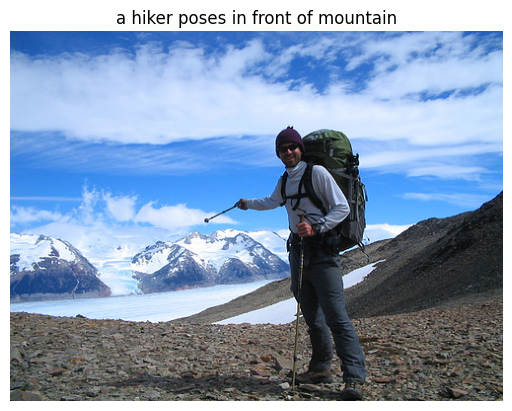

In [11]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img_path = "E:/fortransferee/mlproject7/imagecap/Flicker8k_Dataset/54501196_a9ac9d66f2.jpg"
image = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    encoder_out = encoder(image)
    caption = beam_search(
        encoder_out,
        decoder,
        word2idx,
        idx2word,
        beam_size=3
    )

print("📝 Generated Caption:")
print(caption)

plt.imshow(Image.open(img_path))
plt.axis("off")
plt.title(caption)
plt.show()


In [1]:
import torch
from PIL import Image
from torchvision import transforms

def generate_caption(image, encoder, decoder, beam_size=3):
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    image = image.to(next(encoder.parameters()).device)

    with torch.no_grad():
        encoder_out = encoder(image)
        caption = beam_search(encoder_out, decoder, word2idx, idx2word, beam_size)

    return caption
